In [2]:
import json
import polars as pl
from pathlib import Path
import pandas as pd
import numpy as np
from datetime import date
import stacksats

In [3]:
btc_df = pl.read_parquet('../data/processed/bitcoin_analytics_train.parquet')

In [4]:
btc_df

date,price_usd,mvrv,adjusted_sopr,adjusted_sopr_7d_ema,realized_cap_growth_rate,market_cap_growth_rate
date,f64,f64,f64,f64,f64,f64
2018-01-01,13466.31,2.697882,1.00103,1.037615,1102.8148,1315.791
2018-01-02,14888.11,2.9440713,1.071507,1.046088,1104.3805,1429.6768
2018-01-03,15098.14,3.0010648,1.055439,1.048426,1105.2825,1438.38
2018-01-04,15144.99,2.9857016,1.064714,1.052498,1101.5583,1297.2197
2018-01-05,16960.01,3.2850192,1.107543,1.066259,1104.8623,1658.4019
…,…,…,…,…,…,…
2023-12-27,43337.18,1.9882541,1.081279,1.042915,11.989546,163.99515
2023-12-28,42577.15,1.9477509,1.019564,1.037077,12.232553,161.89229
2023-12-29,41965.03,1.9214514,1.030247,1.03537,12.499344,156.78413


- the mvrv stat only use price_usd and mvrv -> the remain cols is not used
- technically the sopr is used to create like brk_flow, brk_roi_context, and brk_supply_pressure -> but not use in model -> stacksats/features/providers.py

stacksats/features/providers.py
- BRKOverlayFeatureProvider
    - the lagged cols at the ends - 21 columsn -> 
- CoreModelFeatureProvider

# use the BRKOverlayFeatureProvider lagged cols along side mvrv strategy

In [5]:
import polars as pl
import numpy as np
from stacksats import StrategyRunner, ExportConfig, UniformStrategy
from stacksats.strategy_types import BaseStrategy, StrategyContext
from stacksats.model_development import compute_preference_scores
import stacksats.framework_contract
import stacksats.runner.validation

# 0. Apply the 0.0 floor patch to allow extreme hoarding/buying
patch_val = 0.0
stacksats.framework_contract.MIN_DAILY_WEIGHT = patch_val
stacksats.runner.validation.MIN_DAILY_WEIGHT = patch_val

# ---------------------------------------------------------
# 1. DEFINE OUR NEW MACRO STRATEGY
# ---------------------------------------------------------
class AdvancedMacroStrategy(BaseStrategy):
    strategy_id = "advanced_macro_mvrv"
    
    # Tell the engine we want BOTH the basic features AND the dormant BRK overlay features
    def required_feature_sets(self) -> tuple[str, ...]:
        return ("core_model_features_v1", "brk_overlay_v1")

    def build_target_profile(self, ctx: StrategyContext, features_df: pl.DataFrame, signals: dict) -> pl.DataFrame:
        
        # 1. Calculate the standard MVRV preference score as our baseline
        base_scores = compute_preference_scores(
            features_df=features_df,
            start_date=ctx.start_date,
            end_date=ctx.end_date,
        )
        
        # 2. Extract the dormant 'brk_flow' (SOPR Momentum) feature
        # If it's negative, people are capitulating (Good time to buy heavily)
        # If it's positive, people are taking massive profits (Bad time to buy)
        
        brk_features = features_df.select(['date', 'brk_flow'])
        
        # 3. Merge them together
        merged = base_scores.join(brk_features, on='date', how='inner')
        
        # 4. The Macro Overlay Math!
        # We create a modifier based on the SOPR flow.
        # Example: if brk_flow is -2.0 (capitulation), we boost the MVRV score by 30% (multiplier = 1.3)
        # Example: if brk_flow is +2.0 (euphoria), we dampen the MVRV score by 30% (multiplier = 0.7)
        
        merged = merged.with_columns(
            (pl.lit(1.0) - (pl.col('brk_flow') * 0.15)).clip(0.5, 2.0).alias('macro_modifier')
        )
        
        # Apply the modifier to the base preference
        final_scores = merged.with_columns(
            (pl.col('preference') * pl.col('macro_modifier')).alias('value')
        )
        
        return final_scores.select(['date', 'value'])

# ---------------------------------------------------------
# 2. RUN THE BACKTEST
# ---------------------------------------------------------
# Load data
btc_df = pl.read_parquet('../data/processed/bitcoin_analytics_train.parquet')
btc_df = btc_df.with_columns(pl.col('date').cast(pl.Datetime))


#run the above strateygy
runner = StrategyRunner()

macro_dynamic = []
baseline_list = []

print("Running Advanced Macro Strategy (MVRV + SOPR Overlay)...")

for year in range(2018, 2024):
    config = ExportConfig(range_start=f"{year}-01-01", range_end=f"{year}-12-31")
    
    # brand new strategy above AdvancedMacroStrategy!
    dyn = runner.export(AdvancedMacroStrategy(), config, btc_df=btc_df).to_dataframe()

    #the baseline strat
    base = runner.export(UniformStrategy(), config, btc_df=btc_df).to_dataframe()
    
    # Flatten Leap Years
    dyn_flat = dyn.group_by('date').agg([
        pl.col('weight').mean().alias('dynamic_weight'),
        pl.col('price_usd').first()
    ])
    base_flat = base.group_by('date').agg([
        pl.col('weight').mean().alias('baseline_weight')
    ])
    
    macro_dynamic.append(dyn_flat)
    baseline_list.append(base_flat)

# ---------------------------------------------------------
# 3. CALCULATE EXACT SATS
# ---------------------------------------------------------
dynamic_weights = pl.concat(macro_dynamic)
baseline_weights = pl.concat(baseline_list)
merged = dynamic_weights.join(baseline_weights, on='date', how='inner')

merged = merged.with_columns(
    ((pl.col('dynamic_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_dynamic'),
    ((pl.col('baseline_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_baseline')
)

total_macro_sats = merged["sats_accumulated_dynamic"].sum()
total_base_sats = merged["sats_accumulated_baseline"].sum()

print(f"Total Sats accumulated (Advanced Macro Strategy): {total_macro_sats:,.0f} Sats")
print(f"Total Sats accumulated (Baseline DCA): {total_base_sats:,.0f} Sats")


Running Advanced Macro Strategy (MVRV + SOPR Overlay)...
Total Sats accumulated (Advanced Macro Strategy): 45,343 Sats
Total Sats accumulated (Baseline DCA): 50,551 Sats


### explain on the math of modifer:

Let's look at three real-world scenarios to see exactly how the numbers change on a specific day. 

Here is our master equation:
`Modifier = 1.0 - (brk_flow * 0.15)`
`Final Score = Base_MVRV_Score * Modifier`

##### Example 1: The 2022 Bear Market Bottom (Capitulation)
* **The Situation:** Bitcoin has crashed from $60k to $16k. Everyone is panicking.
* **The Data:** MVRV says Bitcoin is super cheap (Base Score = `0.80`). The `brk_flow` shows extreme panic-selling (`-3.0`).
* **The Math:**
  * Modifier = `1.0 - (-3.0 * 0.15)`
  * Modifier = `1.0 + 0.45` = **`1.45`** (A 45% Boost!)
  * Final Score = `0.80 * 1.45` = **`1.16`**
* **The Result:** The model screams "BUY BUY BUY!" with absolute maximum urgency.

##### Example 2: The 2021 Bull Market Peak (Euphoria)
* **The Situation:** Bitcoin hits $69k. Everyone on Twitter is bragging about their profits.
* **The Data:** MVRV says Bitcoin is getting expensive (Base Score = `0.30`). The `brk_flow` shows massive profit-taking (`+2.0`).
* **The Math:**
  * Modifier = `1.0 - (2.0 * 0.15)`
  * Modifier = `1.0 - 0.30` = **`0.70`** (A 30% Penalty!)
  * Final Score = `0.30 * 0.70` = **`0.21`**
* **The Result:** Even though the MVRV model wanted to buy a little bit, our Macro Overlay slapped it down and forced it to hoard cash instead. 

##### Example 3: The COVID "Black Swan" Crash (The Safety Clip)
* **The Situation:** March 2020. The entire global economy halts in one day. 
* **The Data:** Unprecedented panic. `brk_flow` spikes to a mind-blowing `-8.0`.
* **The Math:**
  * Raw Modifier = `1.0 - (-8.0 * 0.15)` = **`2.20`**
  * **The Clip Kicks In:** Because `2.20` is higher than our `.clip(0.5, 2.0)` limit, it gets cut down to **`2.0`**.
* **The Result:** Without the clip, the math would have broken and the model would have dumped its entire year's budget in a single day! The clip safely caps the boost at 2x.

In [5]:
import polars as pl
import datetime as dt
from stacksats.features.providers import BRKOverlayFeatureProvider

# 1. Load your original dataset
btc_df = pl.read_parquet('../data/processed/bitcoin_analytics_train.parquet')
btc_df = btc_df.with_columns(pl.col('date').cast(pl.Datetime))

# 2. Get the start and end dates
start = btc_df['date'].min()
end = btc_df['date'].max()

# 3. Initialize the provider and materialize the features
brk_provider = BRKOverlayFeatureProvider()
brk_features = brk_provider.materialize(
    btc_df,
    start_date=start,
    end_date=end,
    as_of_date=end
)

# 4. Join it with the BTC Price so we have context
brk_table = btc_df.select(['date', 'price_usd']).join(brk_features, on='date', how='inner')

# Display the first 10 rows!
display(brk_table.head(10))

# Or display summary statistics to see the min/max of brk_flow
display(brk_table.select(['brk_flow', 'brk_roi_context', 'brk_supply_pressure', 'brk_netflow']).describe())


date,price_usd,brk_flow,brk_supply_pressure,brk_activity_div,brk_roi_context,brk_liquidity_impulse,brk_miner_pressure,brk_hash_momentum,brk_sentiment,brk_netflow_fast,brk_netflow_slow,brk_netflow_slope,brk_netflow,brk_activity_level,brk_activity_div_fast,brk_activity_div_slow,brk_liquidity_level,brk_exchange_share_level,brk_exchange_share_delta,brk_exchange_share,brk_roi30,brk_roi1y
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2018-01-01 00:00:00,13466.31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-02 00:00:00,14888.11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-03 00:00:00,15098.14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-04 00:00:00,15144.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-05 00:00:00,16960.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-06 00:00:00,17115.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-07 00:00:00,16174.22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-08 00:00:00,15000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-09 00:00:00,14427.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


statistic,brk_flow,brk_roi_context,brk_supply_pressure,brk_netflow
str,f64,f64,f64,f64
"""count""",2191.0,2191.0,2191.0,2191.0
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",0.007823,-0.042076,0.544661,NaN
"""std""",0.942298,1.061477,1.26517,NaN
"""min""",-6.0,-6.0,-2.075991,-6.0
"""25%""",-0.350456,-0.567187,-0.518199,-0.523487
"""50%""",0.0,0.0,0.366016,0.00318
"""75%""",0.356867,0.505986,1.460566,0.562403
"""max""",6.0,6.0,6.0,6.0


## macro modifier - brk_flow

**BRK FLOW**
1. The Core Data (SOPR) - It is built on top of a raw metric called SOPR (Spent Output Profit Ratio). SOPR looks at every single Bitcoin transaction happening right now on the blockchain and asks: "Are these coins moving at a higher price or lower price than when they last moved?"

- SOPR > 1.0: The network as a whole is selling at a profit.
- SOPR < 1.0: The network as a whole is panic-selling at a loss.

2. The Math behind brk_flow - The framework doesn't just use raw SOPR because it's too noisy. Instead, it calculates brk_flow like this:

- It takes the current SOPR and subtracts its 7-day Moving Average.
- It then runs a 240-day rolling Z-score on that difference.

3. How to read - Because it's a Z-score, it usually bounces between -3.0 and +3.0.

- Strongly Positive (e.g., +2.0): The market is in an extreme state of euphoria. People are realizing massive profits compared to the last 8 months. (This usually happens near the top of a bubble).
- Strongly Negative (e.g., -2.0): The market is in total capitulation. People are realizing brutal losses compared to the last 8 months. (This usually happens during major market crashes).
    - this mean people panic selling at BIG LOSS
    - ppl sell bitcoin at this time bought it as much higher price
    - the model might signal when the brk_flow is very negative -> but it might missed the like bigger negative

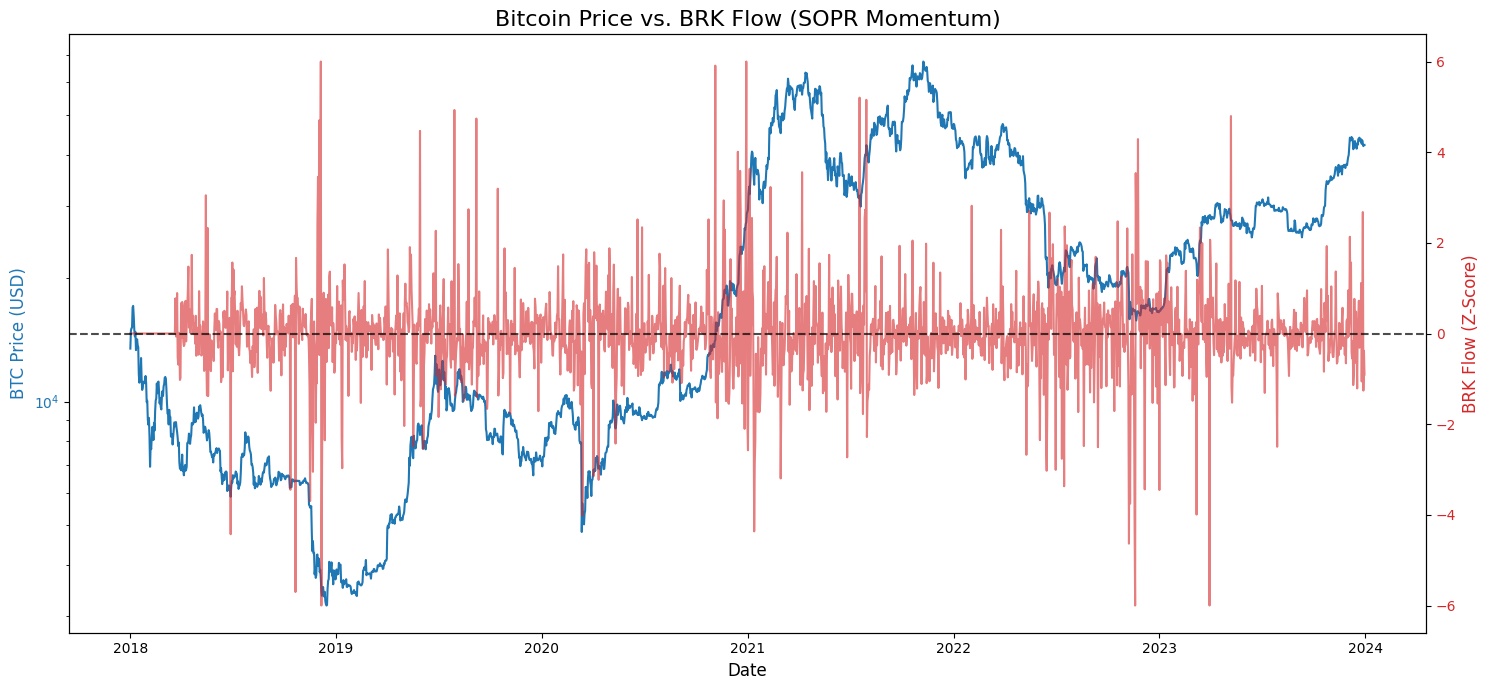

In [7]:
import matplotlib.pyplot as plt

# Assuming the table you generated earlier is named 'brk_table'
# (If you named it something else, just change 'brk_table' below to your variable name)

fig, ax1 = plt.subplots(figsize=(15, 7))

# Plot 1: Bitcoin Price on a log scale (Left Y-Axis)
color = 'tab:blue'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('BTC Price (USD)', color=color, fontsize=12)
ax1.plot(brk_table['date'], brk_table['price_usd'], color=color, label='BTC Price')
ax1.set_yscale('log')
ax1.tick_params(axis='y', labelcolor=color)

# Plot 2: BRK Flow on a linear scale (Right Y-Axis)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('BRK Flow (Z-Score)', color=color, fontsize=12)
ax2.plot(brk_table['date'], brk_table['brk_flow'], color=color, alpha=0.6, label='BRK Flow')
ax2.tick_params(axis='y', labelcolor=color)

# Add a zero-line for brk_flow so you can see positive vs negative easily
ax2.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

# Add a title
plt.title('Bitcoin Price vs. BRK Flow (SOPR Momentum)', fontsize=16)

# Make the layout tight and display
fig.tight_layout()
plt.show()


# new strat with price trend

In [6]:
import polars as pl
from pathlib import Path
from stacksats import StrategyRunner, BacktestConfig, UniformStrategy
from stacksats.strategy_types import BaseStrategy, StrategyContext
from stacksats.model_development import compute_preference_scores
import stacksats.framework_contract
import stacksats.runner.validation

# Turn off the framework's global safety floor so we can hoard cash when needed
patch_val = 1e-05
stacksats.framework_contract.MIN_DAILY_WEIGHT = patch_val
stacksats.runner.validation.MIN_DAILY_WEIGHT = patch_val

class TrendFloorStrategy(BaseStrategy):
    strategy_id = "trend_floor_v1"
    version = "1.0.0"
    
    def required_feature_sets(self) -> tuple[str, ...]:
        return ("core_model_features_v1", "brk_overlay_v1")

    def build_target_profile(self, ctx: StrategyContext, features_df: pl.DataFrame, signals: dict) -> pl.DataFrame:
        
        base_scores = compute_preference_scores(
            features_df=features_df,
            start_date=ctx.start_date,
            end_date=ctx.end_date,
        )
        
        # Grab price and brk_flow so we can calculate the 1-year lookback
        brk_features = features_df.select(['date', 'brk_flow', 'price_usd'])
        merged = base_scores.join(brk_features, on='date', how='inner')
        
        # 1. Create the 1-Year (365 days) lookback columns
        merged = merged.with_columns(
            pl.col('price_usd').shift(365).alias('price_1y_ago'),
            pl.col('brk_flow').shift(365).alias('brk_flow_1y_ago')
        )
        
        # 2. The Logic: Is price 1 year ago NOT 50% higher than today?
        # (If price_1y_ago is <= today * 1.5, we are NOT in a devastating crash)
        condition_price = pl.col('price_1y_ago') <= (pl.col('price_usd') * 1.5)
        
        # Logic: Is brk_flow 1 year ago NOT 50% higher than today?
        condition_flow = pl.col('brk_flow_1y_ago') <= (pl.col('brk_flow') * 1.5)
        
        # 3. Apply the dynamic "Signal Floor" to simulate your 0.00112 rule
        merged = merged.with_columns(
            pl.when(condition_price | condition_flow)
            .then(
                # CONDITION MET: Safe to buy!
                # We double the MVRV score (strong buy signal). 
                # We ALSO enforce a massive artificial floor of 0.8 so the framework is forced to allocate budget!
                pl.max_horizontal(pl.col('preference') * 2.0, pl.lit(0.8)) 
            )
            .otherwise(
                # CONDITION FAILED: We are in a historic crash!
                # Shut off the buying! Hoard cash until the crash ends!
                pl.col('preference') * 0.1 
            )
            .alias('value')
        )
        
        # Fill the first 365 days with neutral scores since we don't have lookback data yet
        return merged.select(['date', 'value']).fill_null(0.5)

# ==========================================
# TEST IT!
# ==========================================
# Load YOUR specific 2018-2023 training data
btc_df = pl.read_parquet('../data/processed/bitcoin_analytics_train.parquet')
btc_df = btc_df.with_columns(pl.col('date').cast(pl.Datetime))
runner = StrategyRunner()

# Restrict the backtest exactly to 2018 - 2023
config = BacktestConfig(start_date="2018-01-01", end_date="2023-12-31")
print("Running New Trend-Floor Strategy (2018-2023)...")
trend_result = runner.backtest(TrendFloorStrategy(), config, btc_df=btc_df)
print(f"-> Trend-Floor Score: {trend_result.score:.2f}")
print(f"-> Trend-Floor Win Rate: {trend_result.win_rate:.1f}%")


# ==========================================
# TOTAL SATS ACCUMULATED TEST (2018-2023)
# ==========================================
macro_dynamic = []
baseline_list = []
print("Running Trend-Floor Strategy to calculate total Sats...")
for year in range(2018, 2024):
    config = ExportConfig(range_start=f"{year}-01-01", range_end=f"{year}-12-31")
    
    # Run the new TrendFloorStrategy!
    dyn = runner.export(TrendFloorStrategy(), config, btc_df=btc_df).to_dataframe()
    base = runner.export(UniformStrategy(), config, btc_df=btc_df).to_dataframe()
    
    # Flatten Leap Years
    dyn_flat = dyn.group_by('date').agg([
        pl.col('weight').mean().alias('dynamic_weight'),
        pl.col('price_usd').first()
    ])
    base_flat = base.group_by('date').agg([
        pl.col('weight').mean().alias('baseline_weight')
    ])
    
    macro_dynamic.append(dyn_flat)
    baseline_list.append(base_flat)
# Tally the results
dynamic_weights = pl.concat(macro_dynamic)
baseline_weights = pl.concat(baseline_list)
merged = dynamic_weights.join(baseline_weights, on='date', how='inner')
merged = merged.with_columns(
    ((pl.col('dynamic_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_dynamic'),
    ((pl.col('baseline_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_baseline')
)
total_macro_sats = merged["sats_accumulated_dynamic"].sum()
total_base_sats = merged["sats_accumulated_baseline"].sum()
print(f"Total Sats accumulated (Trend-Floor Strategy): {total_macro_sats:,.0f} Sats")
print(f"Total Sats accumulated (Baseline DCA): {total_base_sats:,.0f} Sats")

Running New Trend-Floor Strategy (2018-2023)...
-> Trend-Floor Score: 35.63
-> Trend-Floor Win Rate: 41.6%
Running Trend-Floor Strategy to calculate total Sats...
Total Sats accumulated (Trend-Floor Strategy): 49,770 Sats
Total Sats accumulated (Baseline DCA): 50,551 Sats


In [3]:
import polars as pl
from pathlib import Path
from stacksats import StrategyRunner, BacktestConfig, ExportConfig, UniformStrategy
from stacksats.strategy_types import BaseStrategy, StrategyContext
from stacksats.model_development import compute_preference_scores
import stacksats.framework_contract
import stacksats.runner.validation
from stacksats import MVRVStrategy


# ---------------------------------------------------------
# 0. Turn off the framework's global safety floor
# ---------------------------------------------------------
patch_val = 1e-05
stacksats.framework_contract.MIN_DAILY_WEIGHT = patch_val
stacksats.runner.validation.MIN_DAILY_WEIGHT = patch_val

# ---------------------------------------------------------
# 1. Define the Strategy (Your "Value-Investor" Logic)
# ---------------------------------------------------------
class ValueFloorStrategy(BaseStrategy):
    strategy_id = "value_floor_v2"
    version = "1.0.2"
    
    def required_feature_sets(self) -> tuple[str, ...]:
        return ("core_model_features_v1", "brk_overlay_v1")

    def build_target_profile(self, ctx: StrategyContext, features_df: pl.DataFrame, signals: dict) -> pl.DataFrame:
        
        # Get base MVRV scores
        base_scores = compute_preference_scores(
            features_df=features_df,
            start_date=ctx.start_date,
            end_date=ctx.end_date,
        )
        
        # Merge the price data
        brk_features = features_df.select(['date', 'brk_flow', 'price_usd'])
        merged = base_scores.join(brk_features, on='date', how='inner')
        
        # 1-Year Lookback
        merged = merged.with_columns(
            pl.col('price_usd').shift(365).alias('price_1y_ago')
        )
        
        # THE VALUE CONDITION: Is today's price 50% lower than 1 year ago?
        condition_price_crash = pl.col('price_usd') <= (pl.col('price_1y_ago') * 0.4)
        
        # Apply the logic
        merged = merged.with_columns(
            pl.when(condition_price_crash)
            .then(
                # CRASH DETECTED! Turn on the massive 0.8 artificial floor to buy heavily!
                pl.max_horizontal(pl.col('preference') * 2.0, pl.lit(0.6)) 
            )
            .otherwise(
                # NO CRASH. Use normal MVRV score, but dampened so we hoard cash.
                pl.max_horizontal(pl.col('preference') * 0.1, pl.lit(0.00001))
            )
            .alias('value')
        )
        
        return merged.select(['date', 'value']).fill_null(0.5)

# ---------------------------------------------------------
# 2. Setup the Data and Runner
# ---------------------------------------------------------
btc_df = pl.read_parquet('../data/processed/bitcoin_analytics_train.parquet')
btc_df = btc_df.with_columns(pl.col('date').cast(pl.Datetime))

runner = StrategyRunner()

# ---------------------------------------------------------
# 3. Calculate Score and Win Rate (Backtest tool)
# ---------------------------------------------------------
config = BacktestConfig(start_date="2018-01-01", end_date="2023-12-31")

print("Running New Value-Floor Strategy (2018-2023)...")
val_result = runner.backtest(ValueFloorStrategy(), config, btc_df=btc_df)
uni_result = runner.backtest(UniformStrategy(), config, btc_df=btc_df)
mvrv_result = runner.backtest(MVRVStrategy(), config, btc_df=btc_df)

print(f"-> Value-Floor Score: {val_result.score:.2f}")
print(f"-> Value-Floor Win Rate: {val_result.win_rate:.1f}%")
print(f"-> MVRV Score: {mvrv_result.score:.2f}")
print(f"-> MVRV Win Rate: {mvrv_result.win_rate:.1f}%")
print(f"-> Uniform Score: {uni_result.score:.2f}")
print(f"-> Uniform Win Rate: {uni_result.win_rate:.1f}%")

print("-" * 40)
# ---------------------------------------------------------
# 4. Calculate Exact Sats Accumulated (Export tool)
# ---------------------------------------------------------
macro_dynamic = []
mvrv_list = []
baseline_list = []

print("Calculating Total Sats Accumulated...")

for year in range(2018, 2024):
    export_config = ExportConfig(range_start=f"{year}-01-01", range_end=f"{year}-12-31")
    
    # Export all 3 strategies!
    dyn = runner.export(ValueFloorStrategy(), export_config, btc_df=btc_df).to_dataframe()
    mvrv = runner.export(MVRVStrategy(), export_config, btc_df=btc_df).to_dataframe()
    base = runner.export(UniformStrategy(), export_config, btc_df=btc_df).to_dataframe()
    
    dyn_flat = dyn.group_by('date').agg([
        pl.col('weight').mean().alias('dynamic_weight'),
        pl.col('price_usd').first()
    ])
    mvrv_flat = mvrv.group_by('date').agg([
        pl.col('weight').mean().alias('mvrv_weight')
    ])
    base_flat = base.group_by('date').agg([
        pl.col('weight').mean().alias('baseline_weight')
    ])
    
    macro_dynamic.append(dyn_flat)
    mvrv_list.append(mvrv_flat)
    baseline_list.append(base_flat)

# Combine the 6 years
dynamic_weights = pl.concat(macro_dynamic)
mvrv_weights = pl.concat(mvrv_list)
baseline_weights = pl.concat(baseline_list)

# Join them all into one massive table
merged_sats = dynamic_weights.join(baseline_weights, on='date', how='inner')
merged_sats = merged_sats.join(mvrv_weights, on='date', how='inner')

# Calculate the daily sats accumulated for all 3
merged_sats = merged_sats.with_columns(
    ((pl.col('dynamic_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_dynamic'),
    ((pl.col('mvrv_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_mvrv'),
    ((pl.col('baseline_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_baseline')
)

total_macro_sats = merged_sats["sats_accumulated_dynamic"].sum()
total_mvrv_sats = merged_sats["sats_accumulated_mvrv"].sum()
total_base_sats = merged_sats["sats_accumulated_baseline"].sum()

print(f"Total Sats (Value-Floor Strategy): {total_macro_sats:,.0f} Sats")
print(f"Total Sats (MVRV Strategy): {total_mvrv_sats:,.0f} Sats")
print(f"Total Sats (Uniform DCA): {total_base_sats:,.0f} Sats")


Running New Value-Floor Strategy (2018-2023)...
-> Value-Floor Score: 39.42
-> Value-Floor Win Rate: 46.3%
-> MVRV Score: 18.28
-> MVRV Win Rate: 31.3%
-> Uniform Score: 18.65
-> Uniform Win Rate: 0.0%
----------------------------------------
Calculating Total Sats Accumulated...
Total Sats (Value-Floor Strategy): 49,734 Sats
Total Sats (MVRV Strategy): 51,114 Sats
Total Sats (Uniform DCA): 50,551 Sats


In [17]:
merged_sats

date,dynamic_weight,price_usd,baseline_weight,mvrv_weight,sats_accumulated_dynamic,sats_accumulated_mvrv,sats_accumulated_baseline
datetime[μs],f64,f64,f64,f64,f64,f64,f64
2018-01-01 00:00:00,0.00274,13466.31,0.00274,0.00274,20.345039,20.345039,20.345039
2018-01-02 00:00:00,0.00274,14888.11,0.00274,0.00274,18.402108,18.402108,18.402108
2018-01-03 00:00:00,0.00274,15098.14,0.00274,0.00274,18.146116,18.146116,18.146116
2018-01-04 00:00:00,0.00274,15144.99,0.00274,0.00274,18.089982,18.089982,18.089982
2018-01-05 00:00:00,0.00274,16960.01,0.00274,0.00274,16.154035,16.154035,16.154035
…,…,…,…,…,…,…,…
2023-12-27 00:00:00,0.1,43337.18,0.00274,0.1,230.748747,230.748747,6.321883
2023-12-28 00:00:00,0.1,42577.15,0.00274,0.1,234.867764,234.867764,6.434733
2023-12-29 00:00:00,0.1,41965.03,0.00274,0.1,238.293646,238.293646,6.528593


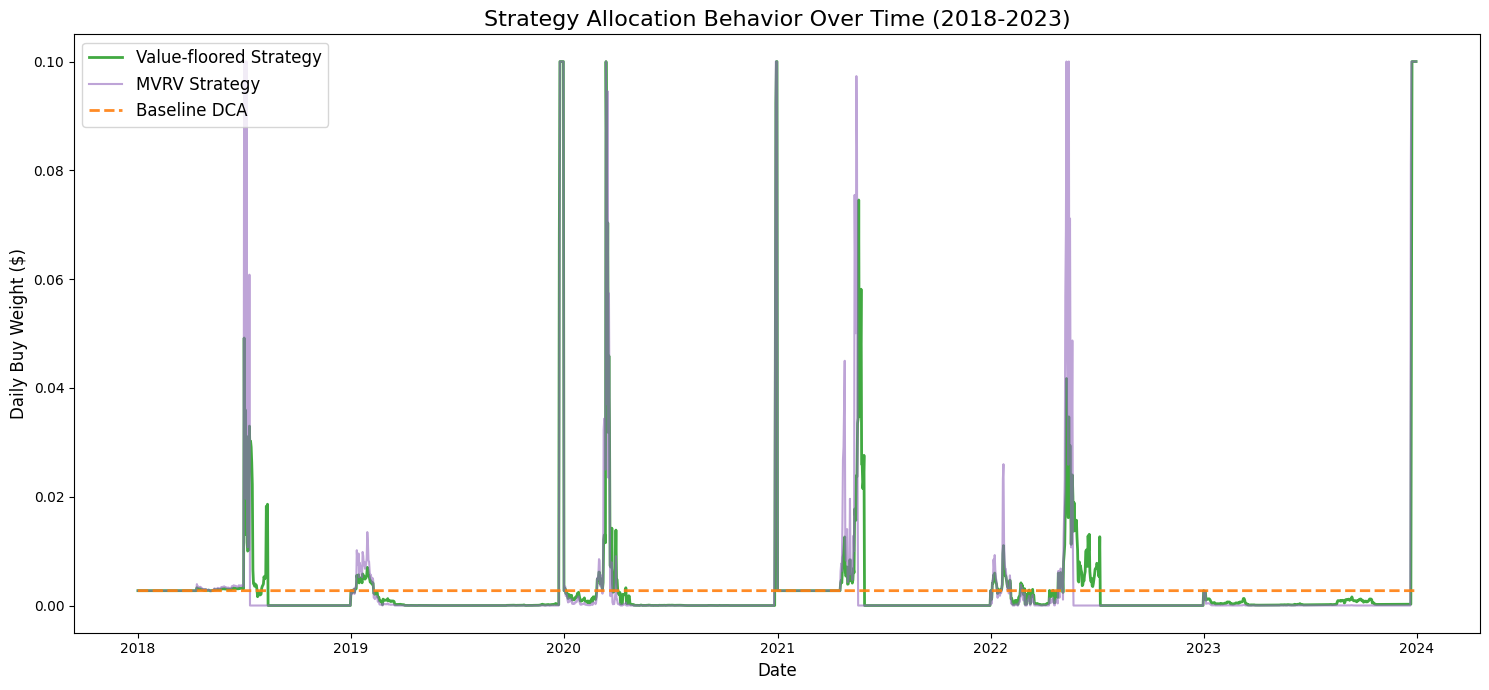

In [19]:
import matplotlib.pyplot as plt

# Make sure the table is sorted chronologically
merged_sats = merged_sats.sort('date')

# Create the chart
fig, ax1 = plt.subplots(figsize=(15, 7))

ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Daily Buy Weight ($)', fontsize=12)

# 1. Plot your Custom Tiered Strategy (Green Line)
ax1.plot(
    merged_sats['date'], merged_sats['dynamic_weight'], 
    color='tab:green', label='Value-floored Strategy', alpha=0.9, linewidth=2
)

# 2. Plot the Factory MVRV Strategy (Purple Line)
ax1.plot(
    merged_sats['date'], merged_sats['mvrv_weight'], 
    color='tab:purple', label='MVRV Strategy', alpha=0.6, linewidth=1.5
)

# 3. Plot the dumb Baseline DCA (Orange Dotted Line)
ax1.plot(
    merged_sats['date'], merged_sats['baseline_weight'], 
    color='tab:orange', label='Baseline DCA', alpha=0.9, linestyle='--', linewidth=2
)

ax1.set_title('Strategy Allocation Behavior Over Time (2018-2023)', fontsize=16)
ax1.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()


## tuning

In [21]:
import polars as pl
from stacksats import StrategyRunner, BacktestConfig

# ---------------------------------------------------------
# 1. The Tunable Strategy
# ---------------------------------------------------------
class TunableValueStrategy(BaseStrategy):
    # We must accept the hyperparameters when we create the class
    def __init__(self, crash_depth, boost, floor, dampen):
        self.crash_depth = crash_depth
        self.boost = boost
        self.floor = floor
        self.dampen = dampen
        
        # We MUST change the strategy_id dynamically so the framework doesn't cache the results!
        self.strategy_id = f"tune_{crash_depth}_{boost}_{floor}_{dampen}"
        self.version = "1.0.0"

    def required_feature_sets(self) -> tuple[str, ...]:
        return ("core_model_features_v1", "brk_overlay_v1")

    def build_target_profile(self, ctx: StrategyContext, features_df: pl.DataFrame, signals: dict) -> pl.DataFrame:
        base_scores = compute_preference_scores(features_df=features_df, start_date=ctx.start_date, end_date=ctx.end_date)
        price_features = features_df.select(['date', 'price_usd'])
        merged = base_scores.join(price_features, on='date', how='inner')
        merged = merged.with_columns(pl.col('price_usd').shift(365).alias('price_1y_ago'))
        
        # Inject our Hyperparameters into the Math!
        condition_crash = pl.col('price_usd') <= (pl.col('price_1y_ago') * self.crash_depth)
        
        merged = merged.with_columns(
            pl.when(condition_crash)
            .then(
                pl.max_horizontal(pl.col('preference') * self.boost, pl.lit(self.floor)) 
            )
            .otherwise(
                pl.max_horizontal(pl.col('preference') * self.dampen, pl.lit(0.00001))
            )
            .alias('value')
        )
        return merged.select(['date', 'value']).fill_null(0.5)

# ---------------------------------------------------------
# 2. The Grid Search (Hyperparameter Tuning Loop)
# ---------------------------------------------------------
runner = StrategyRunner()
config = BacktestConfig(start_date="2018-01-01", end_date="2023-12-31")

# The values you want to test! 
# (Keep the lists short so it doesn't take 5 hours to run)
crash_depths = [0.4, 0.5, 0.6]  # Try 40% drop, 50% drop, 60% drop
boosts       = [2.0, 3.0, 4.0]  # Try doubling, tripling, quadrupling
floors       = [0.6, 0.8, 1.0]  # Try moderate floor, heavy floor, absolute max floor
dampens      = [0.1, 0.3, 0.5]  # Try heavy hoarding (0.1) vs light hoarding (0.5)

leaderboard = []

print(f"Starting Grid Search. Testing {len(crash_depths) * len(boosts) * len(floors) * len(dampens)} combinations...")

for c in crash_depths:
    for b in boosts:
        for f in floors:
            for d in dampens:
                
                # Create the strategy with the current settings
                strat = TunableValueStrategy(crash_depth=c, boost=b, floor=f, dampen=d)
                
                # Run the backtest
                result = runner.backtest(strat, config, btc_df=btc_df)
                
                # Save the results
                leaderboard.append({
                    "Crash_Depth": c,
                    "Boost": b,
                    "Floor": f,
                    "Dampen": d,
                    "Score": float(result.score),
                    "Win_Rate": float(result.win_rate)
                })

# Convert leaderboard to Polars DataFrame and sort by Score
results_df = pl.DataFrame(leaderboard).sort("Score", descending=True)

print("\n🏆 HYPERPARAMETER GRID SEARCH WINNERS 🏆")
display(results_df.head(10))


Starting Grid Search. Testing 81 combinations...

🏆 HYPERPARAMETER GRID SEARCH WINNERS 🏆


Crash_Depth,Boost,Floor,Dampen,Score,Win_Rate
f64,f64,f64,f64,f64,f64
0.4,2.0,0.6,0.1,39.421274,46.305419
0.4,2.0,0.8,0.1,39.421274,46.305419
0.4,2.0,1.0,0.1,39.421274,46.305419
0.4,3.0,0.6,0.1,39.421274,46.305419
0.4,3.0,0.8,0.1,39.421274,46.305419
0.4,3.0,1.0,0.1,39.421274,46.305419
0.4,4.0,0.6,0.1,39.421274,46.305419
0.4,4.0,0.8,0.1,39.421274,46.305419
0.4,4.0,1.0,0.1,39.421274,46.305419


## math

Absolutely. The **Value-Floor Strategy** is mathematically designed to be the ultimate contrarian: it does absolutely nothing until there is blood in the streets.

Here is the exact step-by-step breakdown of how the math makes decisions:

### Step 1: The Time Machine
```python
pl.col('price_usd').shift(365).alias('price_1y_ago')
```
For every single day in the simulation, it reaches back exactly 365 days to grab the price of Bitcoin 1 year ago.

### Step 2: The "50% Crash" Detector
```python
condition_price_crash = pl.col('price_usd') <= (pl.col('price_1y_ago') * 0.5)
```
This is the core rule. We take the price from 1 year ago and multiply it by `0.5` (cutting it in half). Then we compare it to today's price.
* Let's say 1 year ago the price was **$60,000**. Half of that is **$30,000**.
* It asks: *"Is today's price less than or equal to $30,000?"*
* **If YES:** We are in a devastating crash. Bitcoin has lost 50%+ of its value in the last year.
* **If NO:** We are NOT in a devastating crash. Bitcoin might be sideways or even in a bull market.

### Step 3: The Green Light (Crash Detected!)
```python
pl.when(condition_price_crash)
.then(
    pl.max_horizontal(pl.col('preference') * 2.0, pl.lit(0.8)) 
)
```
If the math detects we are in a massive 50% crash, the traffic light turns GREEN. 
* First, we double whatever the MVRV model says (`preference * 2.0`) to make it aggressive.
* Then we apply the **Artificial Floor** using `pl.max_horizontal( ..., 0.8)`. 
* This tells the math: *"Compare the doubled score with `0.8`. Whichever is HIGHER becomes the final answer."* This mathematically guarantees that during a crash, the buy signal is massive. It forces the model to dump its cash at the absolute bottom.

### Step 4: The Red Light (Hoard Cash)
```python
.otherwise(
    pl.col('preference') * 0.5 
)
```
If the math says we are NOT in a crash (for example, during 2019, 2020, and 2021), the traffic light turns RED.
* It takes the standard MVRV score and cuts it in half (`* 0.5`).
* This forcefully dampens the model, making it too scared to buy. It hoards almost all of its cash year after year, patiently waiting for the 50% crash condition to finally trigger!

## graph

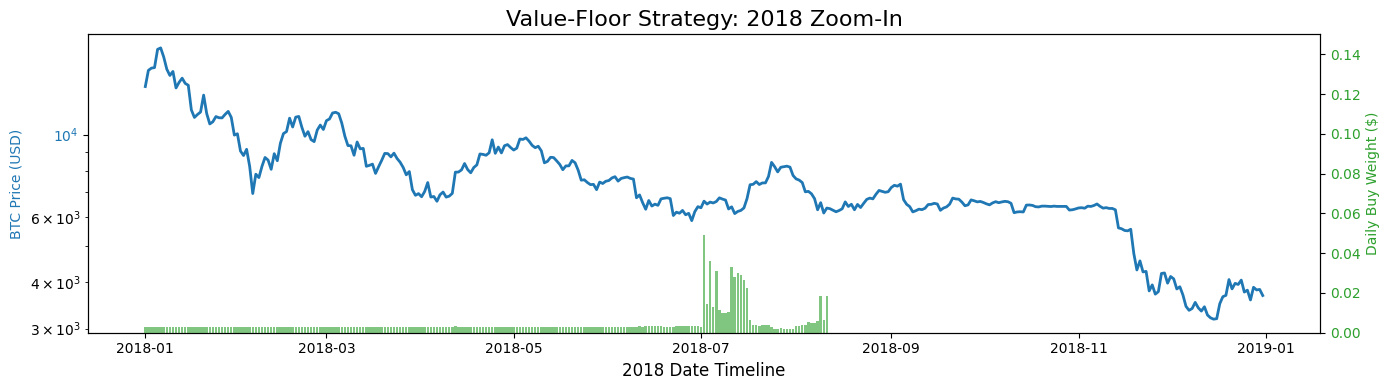

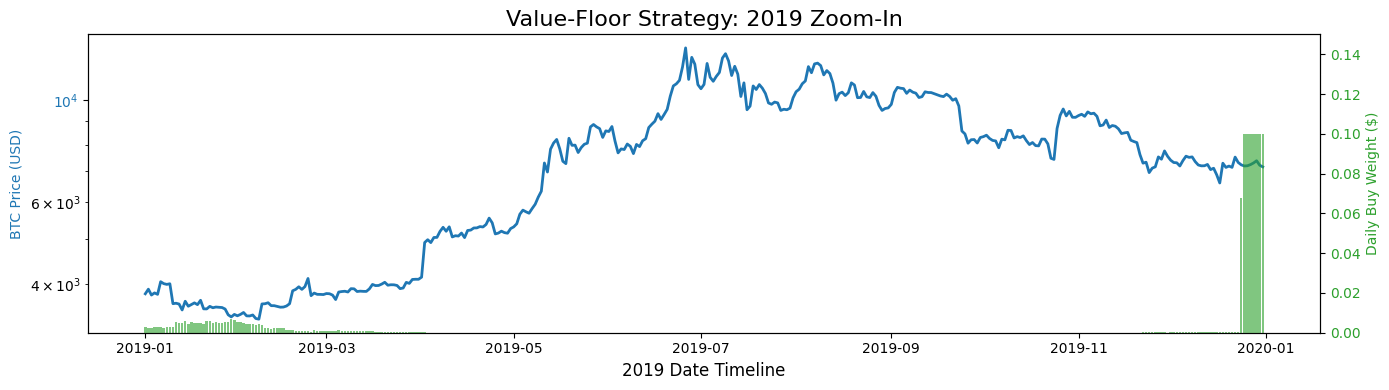

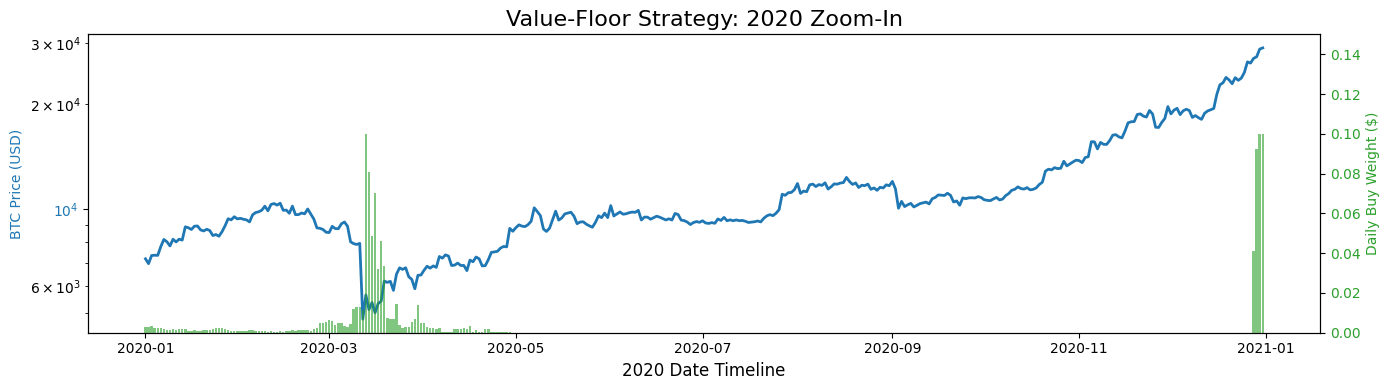

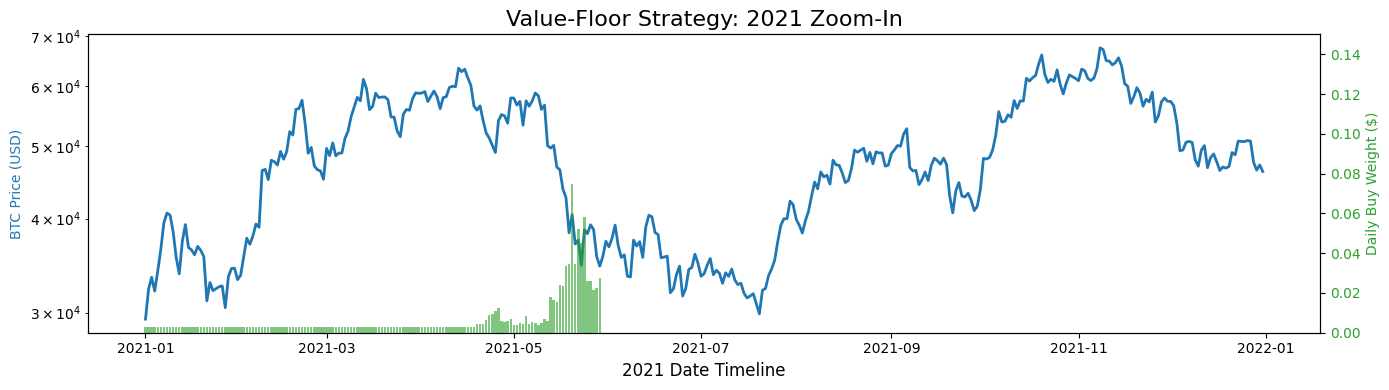

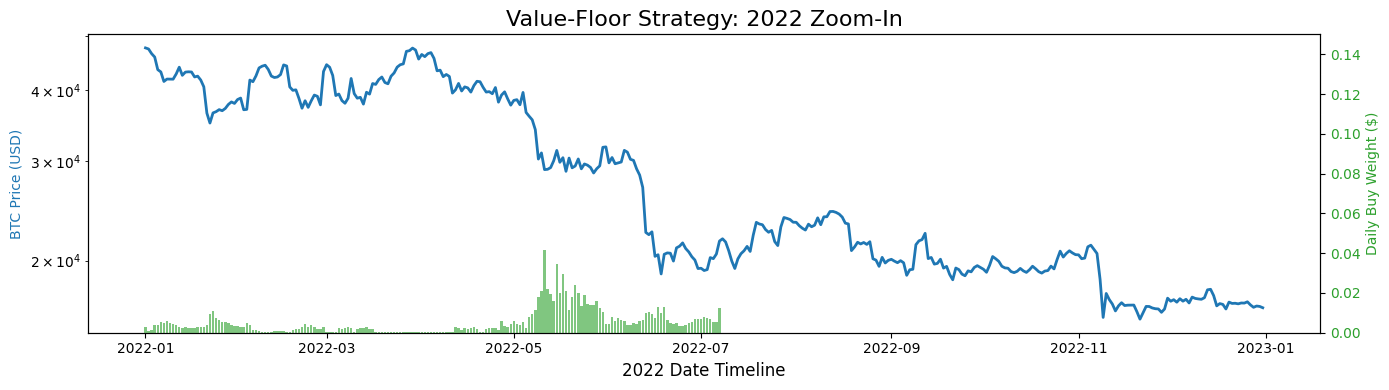

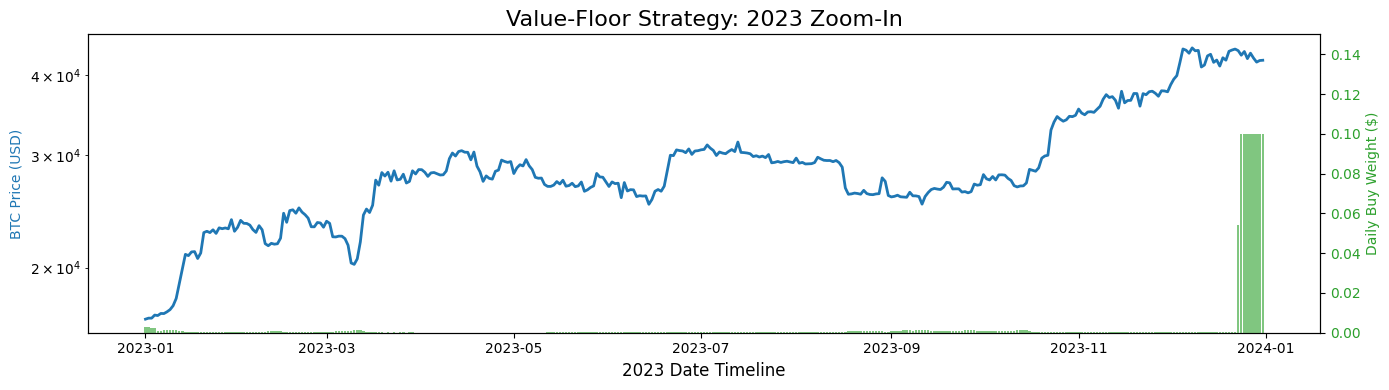

In [8]:
import matplotlib.pyplot as plt

# Make sure the table is sorted chronologically
dynamic_weights = dynamic_weights.sort('date')

# Loop through each year from 2018 to 2023
for year in range(2018, 2024):
    
    # Filter the Polars DataFrame to only keep rows from this specific year
    year_data = dynamic_weights.filter(
        pl.col('date').dt.year() == year
    )
    
    # Create the chart
    fig, ax1 = plt.subplots(figsize=(14, 4)) # Wide and short for perfect scrolling

    # 1. Plot Bitcoin Price (Left Axis - Log Scale)
    color = 'tab:blue'
    ax1.set_xlabel(f'{year} Date Timeline', fontsize=12)
    ax1.set_ylabel('BTC Price (USD)', color=color)
    ax1.plot(year_data['date'], year_data['price_usd'], color=color, linewidth=2)
    ax1.set_yscale('log')
    ax1.tick_params(axis='y', labelcolor=color)

    # 2. Plot Strategy Buying Weights (Right Axis - Bar Chart)
    ax2 = ax1.twinx()
    color = 'tab:green'
    ax2.set_ylabel('Daily Buy Weight ($)', color=color)
    ax2.bar(year_data['date'], year_data['dynamic_weight'], color=color, alpha=0.6)
    
    # Optional: We lock the Y-axis maximum at $0.15 (15 cents) for all charts 
    # so the green bars are visually proportional across all years
    ax2.set_ylim(0, 0.15) 
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Value-Floor Strategy: {year} Zoom-In', fontsize=16)
    fig.tight_layout()
    plt.show()


# 50% -> buy lot, 20% buy min

In [26]:
import polars as pl
from pathlib import Path
from stacksats import StrategyRunner, BacktestConfig, ExportConfig, UniformStrategy
from stacksats.strategy_types import BaseStrategy, StrategyContext
from stacksats.model_development import compute_preference_scores
import stacksats.framework_contract
import stacksats.runner.validation
import stacksats.strategy_types._legacy # <--- Import the legacy file

# ---------------------------------------------------------
# 0. Turn off ALL 3 of the framework's global safety floors!
# ---------------------------------------------------------
patch_val = 0.0
stacksats.framework_contract.MIN_DAILY_WEIGHT = patch_val
stacksats.runner.validation.MIN_DAILY_WEIGHT = patch_val
stacksats.strategy_types._legacy.MIN_DAILY_WEIGHT = patch_val # <--- Hack the 3rd safety rail!

# ---------------------------------------------------------
# 1. Define the Strategy (Tiered Accumulation)
# ---------------------------------------------------------
class TieredValueStrategy(BaseStrategy):
    strategy_id = "tiered_value_v1"
    version = "1.0.0"
    
    def required_feature_sets(self) -> tuple[str, ...]:
        return ("core_model_features_v1", "brk_overlay_v1")

    def build_target_profile(self, ctx: StrategyContext, features_df: pl.DataFrame, signals: dict) -> pl.DataFrame:
        
        base_scores = compute_preference_scores(
            features_df=features_df,
            start_date=ctx.start_date,
            end_date=ctx.end_date,
        )
        
        price_features = features_df.select(['date', 'price_usd'])
        merged = base_scores.join(price_features, on='date', how='inner')
        
        # 1-Year Lookback
        merged = merged.with_columns(
            pl.col('price_usd').shift(365).alias('price_1y_ago')
        )
        
        # TIERED CRASH CONDITIONS
        condition_severe = pl.col('price_usd') <= (pl.col('price_1y_ago') * 0.5)
        condition_mild = pl.col('price_usd') <= (pl.col('price_1y_ago') * 0.8)
        
        # Apply the logic
        merged = merged.with_columns(
            pl.when(condition_severe)
            .then(
                pl.max_horizontal(pl.col('preference') * 2.0, pl.lit(0.8)) 
            )
            .when(condition_mild)
            .then(
                pl.max_horizontal(pl.col('preference') * 1.2, pl.lit(0.2)) 
            )
            .otherwise(
                # Revert to normal hoarding
                pl.col('preference') * 0.1 
            )
            .alias('value')
        )
        
        return merged.select(['date', 'value']).fill_null(0.5)

# ---------------------------------------------------------
# 2. Setup the Data and Runner
# ---------------------------------------------------------
btc_df = pl.read_parquet('../data/processed/bitcoin_analytics_train.parquet')
btc_df = btc_df.with_columns(pl.col('date').cast(pl.Datetime))

runner = StrategyRunner()

# ---------------------------------------------------------
# 3. Calculate Score and Win Rate (Backtest tool)
# ---------------------------------------------------------
config = BacktestConfig(start_date="2018-01-01", end_date="2023-12-31")

print("Running Tiered Value Strategy (2018-2023)...")
val_result = runner.backtest(TieredValueStrategy(), config, btc_df=btc_df)
print(f"-> Tiered Value Score: {val_result.score:.2f}")
print(f"-> Tiered Value Win Rate: {val_result.win_rate:.1f}%")
print("-" * 40)

# ---------------------------------------------------------
# 4. Calculate Exact Sats Accumulated (Export tool)
# ---------------------------------------------------------
macro_dynamic = []
baseline_list = []

print("Calculating Total Sats Accumulated...")

for year in range(2018, 2024):
    export_config = ExportConfig(range_start=f"{year}-01-01", range_end=f"{year}-12-31")
    
    dyn = runner.export(TieredValueStrategy(), export_config, btc_df=btc_df).to_dataframe()
    base = runner.export(UniformStrategy(), export_config, btc_df=btc_df).to_dataframe()
    
    dyn_flat = dyn.group_by('date').agg([
        pl.col('weight').mean().alias('dynamic_weight'),
        pl.col('price_usd').first()
    ])
    base_flat = base.group_by('date').agg([
        pl.col('weight').mean().alias('baseline_weight')
    ])
    
    macro_dynamic.append(dyn_flat)
    baseline_list.append(base_flat)

dynamic_weights = pl.concat(macro_dynamic)
baseline_weights = pl.concat(baseline_list)
merged_sats = dynamic_weights.join(baseline_weights, on='date', how='inner')

merged_sats = merged_sats.with_columns(
    ((pl.col('dynamic_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_dynamic'),
    ((pl.col('baseline_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_baseline')
)

total_macro_sats = merged_sats["sats_accumulated_dynamic"].sum()
total_base_sats = merged_sats["sats_accumulated_baseline"].sum()

print(f"Total Sats accumulated (Tiered Value Strategy): {total_macro_sats:,.0f} Sats")
print(f"Total Sats accumulated (Baseline DCA): {total_base_sats:,.0f} Sats")

Running Tiered Value Strategy (2018-2023)...
-> Tiered Value Score: 35.66
-> Tiered Value Win Rate: 41.7%
----------------------------------------
Calculating Total Sats Accumulated...
Total Sats accumulated (Tiered Value Strategy): 49,768 Sats
Total Sats accumulated (Baseline DCA): 50,551 Sats


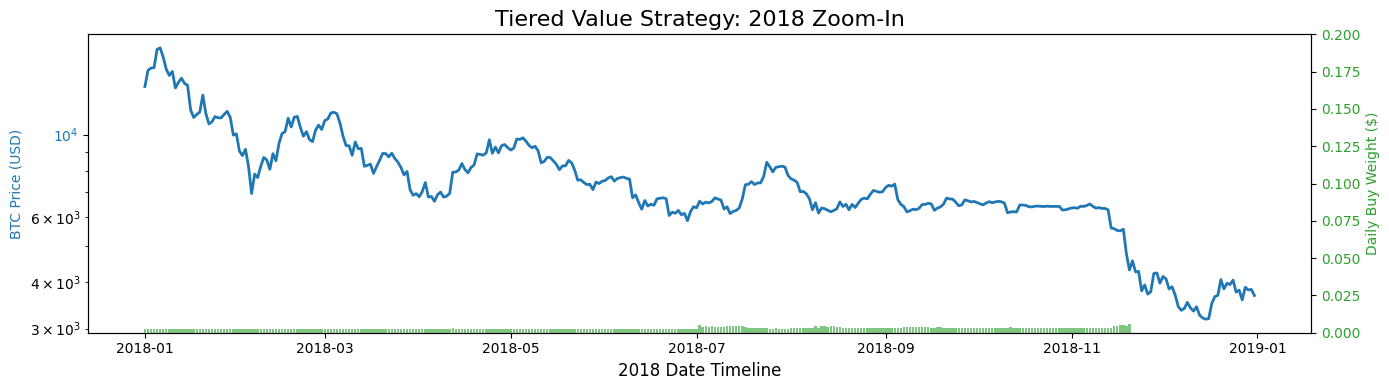

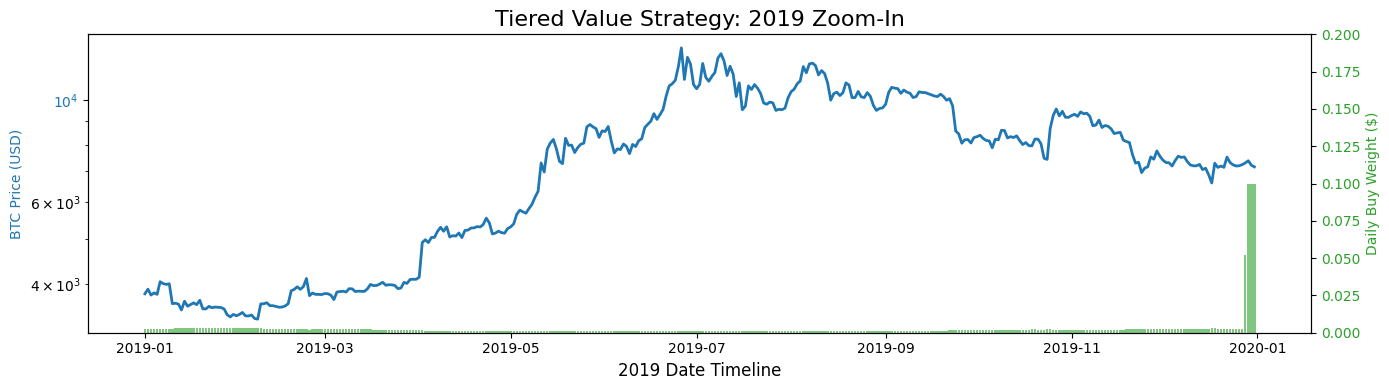

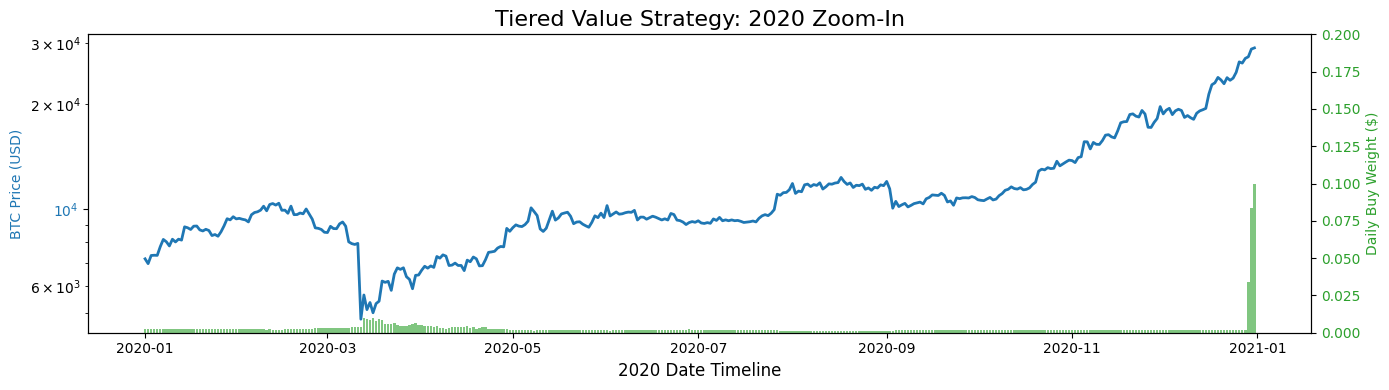

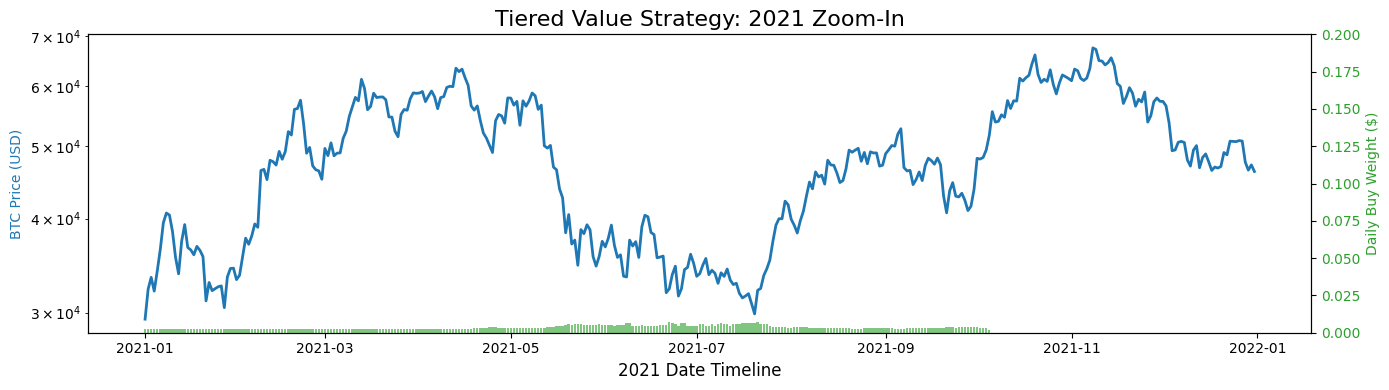

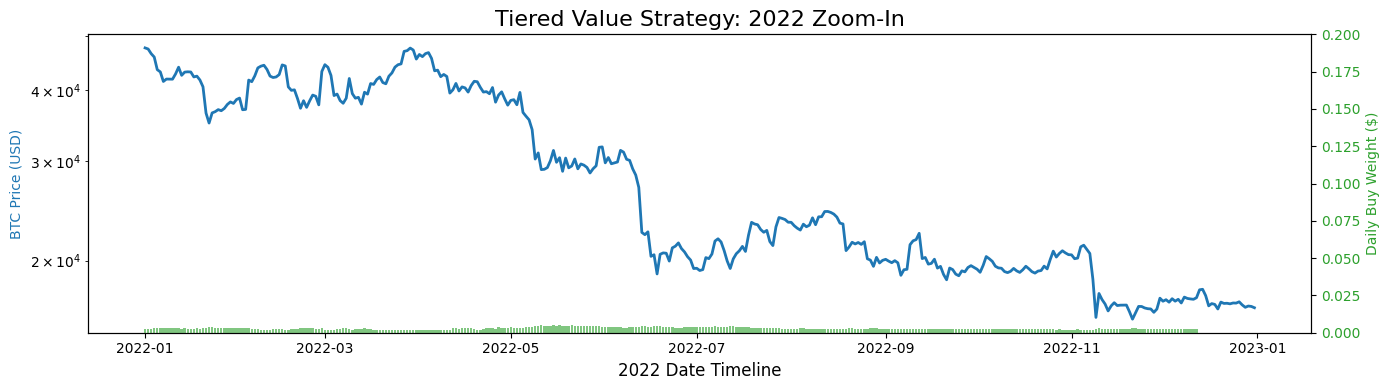

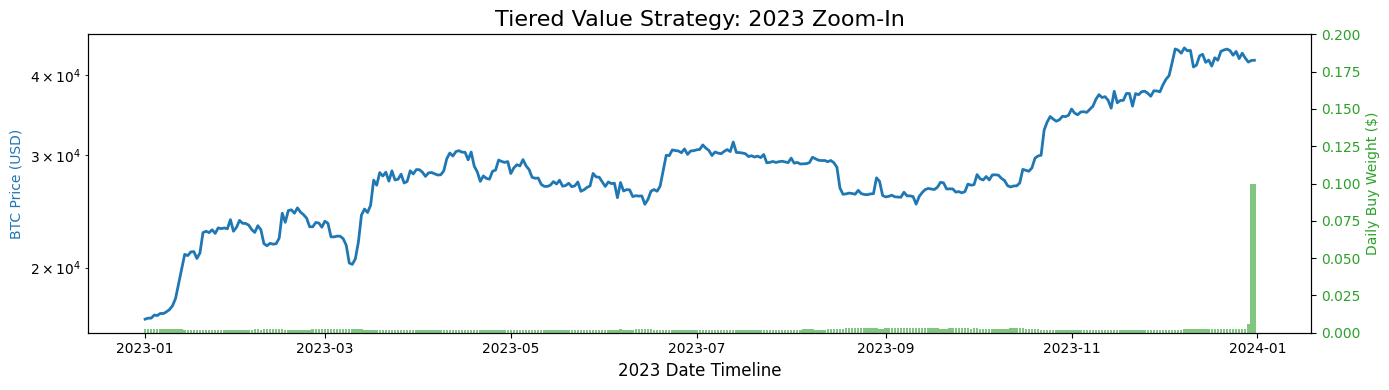

In [20]:
import matplotlib.pyplot as plt

# 1. Make sure the table is sorted chronologically to avoid the "spiderweb" glitch
dynamic_weights = dynamic_weights.sort('date')

# 2. Loop through each year from 2018 to 2023
for year in range(2018, 2024):
    
    # Filter the Polars DataFrame to only keep rows from this specific year
    year_data = dynamic_weights.filter(
        pl.col('date').dt.year() == year
    )
    
    # Create the chart (Wide and short for perfect scrolling)
    fig, ax1 = plt.subplots(figsize=(14, 4)) 

    # Plot Bitcoin Price (Left Axis - Log Scale)
    color = 'tab:blue'
    ax1.set_xlabel(f'{year} Date Timeline', fontsize=12)
    ax1.set_ylabel('BTC Price (USD)', color=color)
    ax1.plot(year_data['date'], year_data['price_usd'], color=color, linewidth=2)
    ax1.set_yscale('log')
    ax1.tick_params(axis='y', labelcolor=color)

    # Plot Strategy Buying Weights (Right Axis - Bar Chart)
    ax2 = ax1.twinx()
    color = 'tab:green'
    ax2.set_ylabel('Daily Buy Weight ($)', color=color)
    ax2.bar(year_data['date'], year_data['dynamic_weight'], color=color, alpha=0.6)
    
    # Lock the Y-axis maximum at $0.20 (20 cents) so it is proportional across all years
    ax2.set_ylim(0, 0.20) 
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Tiered Value Strategy: {year} Zoom-In', fontsize=16)
    fig.tight_layout()
    plt.show()
